# Run an initial LLOWFSC calibration assuming the DM flat command is applied and we are well aligned to the vortex mask. 

In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
from datetime import timezone 
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, coro_utils
from lina import llowfsc, rt_utils, dm

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

data_path = Path(f'../data/{today}-llowfsc')
utils.make_dir(data_path)


INFO:numexpr.utils:NumExpr defaulting to 12 threads.
/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Directory '../data/20260427-llowfsc' already exists.


INFO:purepyindi2.transports:Connected to localhost:7624


# Connect to the SHMIM streams.

In [2]:
reload(coro_utils)

cam_channel = 'camlo294'

xc, yc = (6000, 2820)
xc, yc = (7000, 1500)
ncam = 1024

xc, yc = (5290, 5570)
# ncam = 1024
ncam = 64

coro_utils.set_cam_roi(xc, yc, ncam, client0, cam_name=cam_channel, bin_mode=2, delay=0.5)
coro_utils.set_cam_exp_time(0.0001, client0, cam_name=cam_channel)
coro_utils.set_cam_gain(0, client0, cam_name=cam_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=cam_channel)

Set camlo294 ROI.
Set the camlo294 exposure time to 1.00e-04s
Set the camlo294 gain setting to 0.0
Set the camlo294 blacklevel to 2.0


In [3]:
coro_utils.set_cam_exp_time(0.0001, client0, cam_name=cam_channel)

Set the camlo294 exposure time to 1.00e-04s


In [4]:
coro_utils.set_cam_gain(0, client0, cam_name=cam_channel)

Set the camlo294 gain setting to 0.0


In [5]:
coro_utils.set_cam_blacklevel(2, client0, cam_name=cam_channel)

Set the camlo294 blacklevel to 2.0


In [6]:
reload(coro_utils)
coro_utils.set_fiber_atten(0, client0)

Set the fiber attenuation to 0.0


In [7]:
reload(coro_utils)
coro_utils.home_block(client0, delay=2.0)

In [ ]:
coro_utils.move_block_out(client0)

In [ ]:
reload(coro_utils)
coro_utils.move_psf(1, 0, client0)

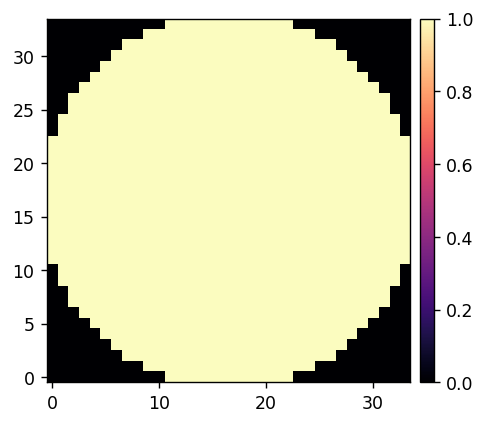

In [8]:
CAMLO_STREAM = ImageStream('camlo294')

DM_STREAMS = []
for i in range(1,11):
    DM_STREAMS.append(ImageStream(f'dm00disp{i:02}'))

rt_utils.create_shmim('llowfsc_zpo', (CAMLO_STREAM.shape[0], CAMLO_STREAM.shape[1]))
ZPO_STREAM = ImageStream('llowfsc_zpo')

rt_utils.create_shmim('llowfsc_gains', (10, 1))
GAINS_STREAM = ImageStream('llowfsc_gains')
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.05]))

Ncamlo = CAMLO_STREAM.shape[0]
Nact = DM_STREAMS[0].shape[0]

dm_mask = dm.create_mask(Nact=Nact, return_np=1)
utils.imshow(
    [dm_mask]
)

In [10]:
def take_im_fun(
        CAMLO_STREAM,
        NFRAMES=1,
    ):
    camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0)
    # camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0) if NFRAMES>1 else CAMLO_STREAM.grab_after(1,0)[0]
    return camlo_im

take_im_params = {
    'CAMLO_STREAM':CAMLO_STREAM,
    'NFRAMES':1,
}

def set_dm_fun(
        command,
        DM_STREAM,
    ):

    DM_STREAM.write(1e6*ensure_np_array(command))

set_dm_params = {
    'DM_STREAM':ImageStream('dm00disp01'),
}

def get_dm_fun(
        DM_STREAM,
    ):

    return 1e-6*DM_STREAM.grab_latest()


get_dm_params = {
    'DM_STREAM':ImageStream('dm00disp01'),
}

def get_gains():
    return GAINS_STREAM.grab_latest()[0]

def get_zpo(ZPO_STREAM):
    return ZPO_STREAM.grab_latest()

get_zpo_params = {
    'ZPO_STREAM':ZPO_STREAM,
}

# Obtain a reference dark image for the camera settings that will be used during the duration of LLOWFSC.

In [11]:
coro_utils.move_block_in(client0)

INFO:utils:Got semaphore index 1.


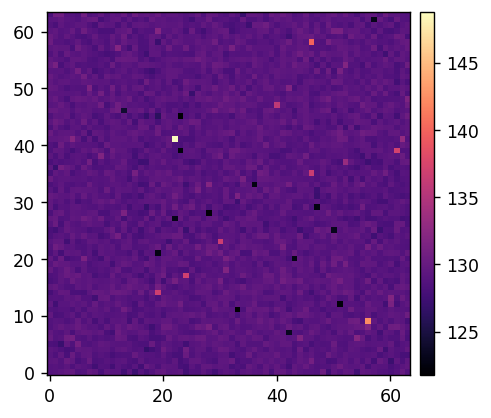

In [12]:

take_im_params.update({
    'NFRAMES':200,
})

camlo_dark = take_im_fun(**take_im_params)

utils.imshow([camlo_dark])

In [13]:
coro_utils.move_block_out(client0)

# Obtain the reference image.

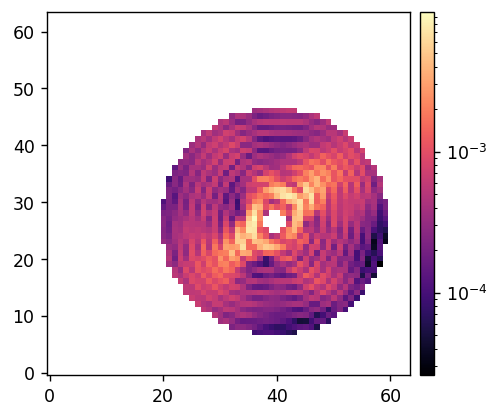

In [55]:
reload(llowfsc)

irad = 2
orad = 20
wfs_mask = utils.create_annular_focal_plane_mask(
    CAMLO_STREAM.shape[0], 
    1, 
    irad, 
    orad, 
    edge=None, 
    x_shift=8,
    y_shift=-5,
    centering='even', 
    return_np=1,
)

take_im_params.update({
    'NFRAMES':100,
})

ref_im, flux_norm_coeff = llowfsc.acquire_ref(
    take_im_fun,
    take_im_params,
    wfs_mask,
    camlo_dark=camlo_dark,
    flux_norm=True,
)

utils.imshow(
    [ref_im],
    norms=[LogNorm()] 
)


# Calibrate for the set of Zernike modes that we want to control.

Calibrated mode 1/10 in 0.276s

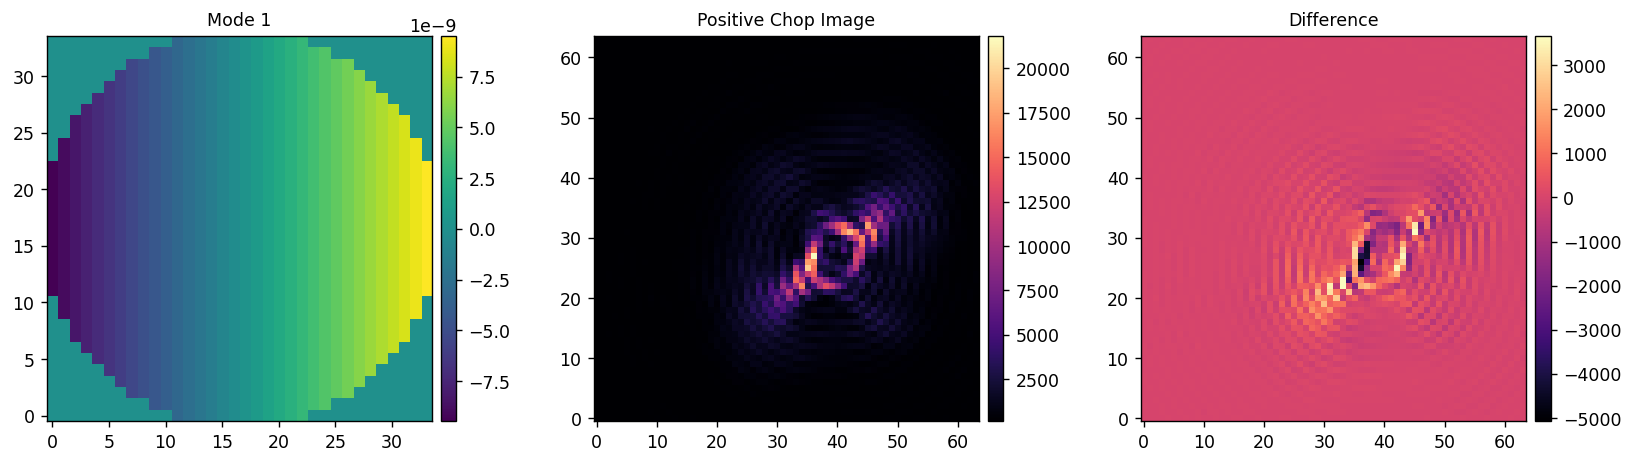

Calibrated mode 2/10 in 1.273s

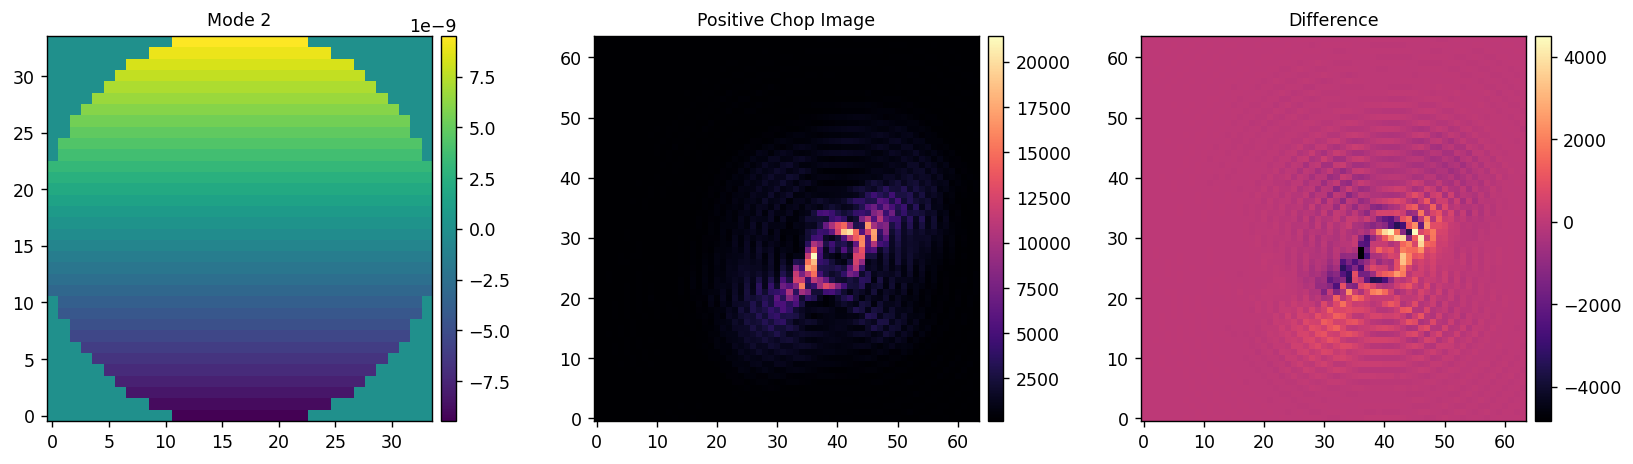

Calibrated mode 3/10 in 2.020s

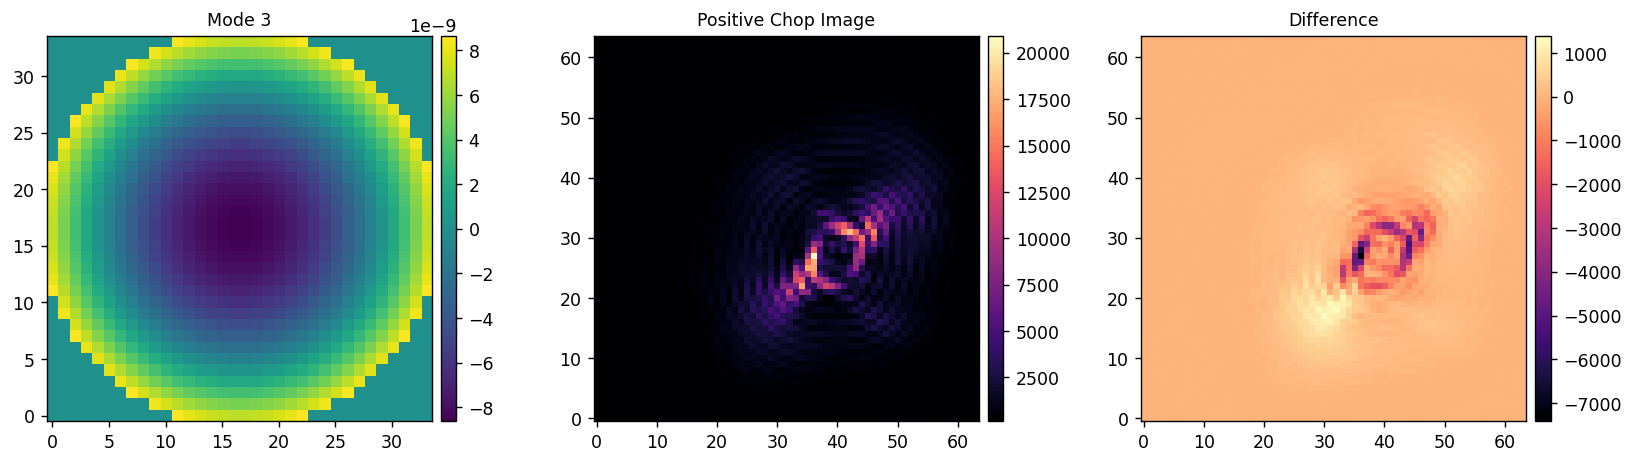

Calibrated mode 4/10 in 2.823s

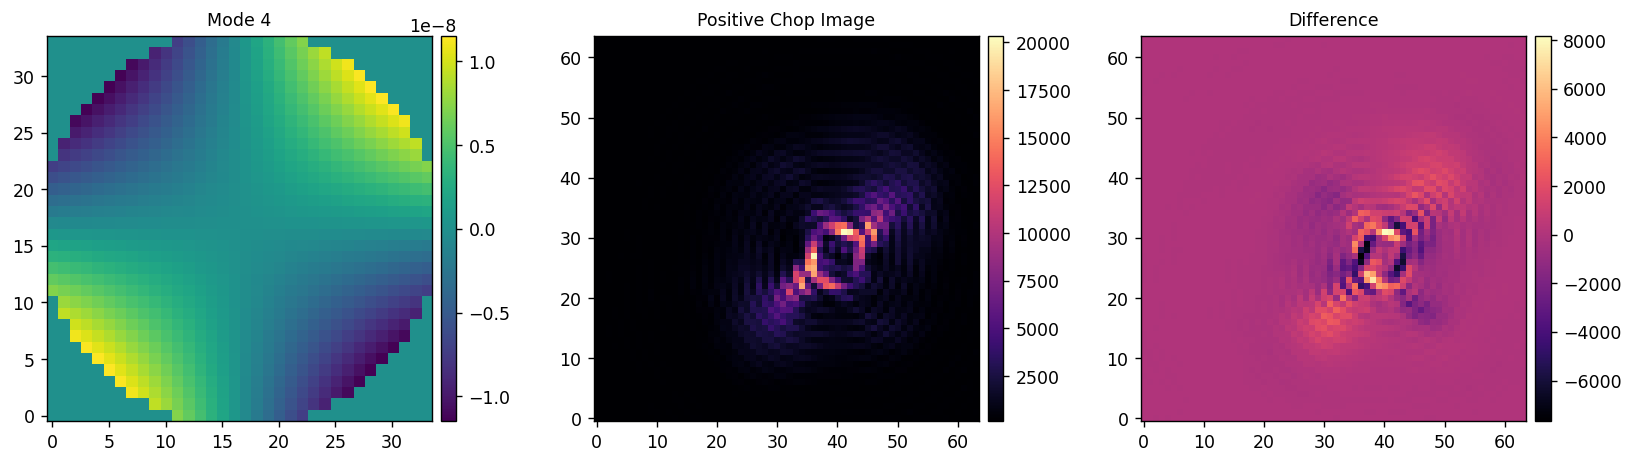

Calibrated mode 5/10 in 3.554s

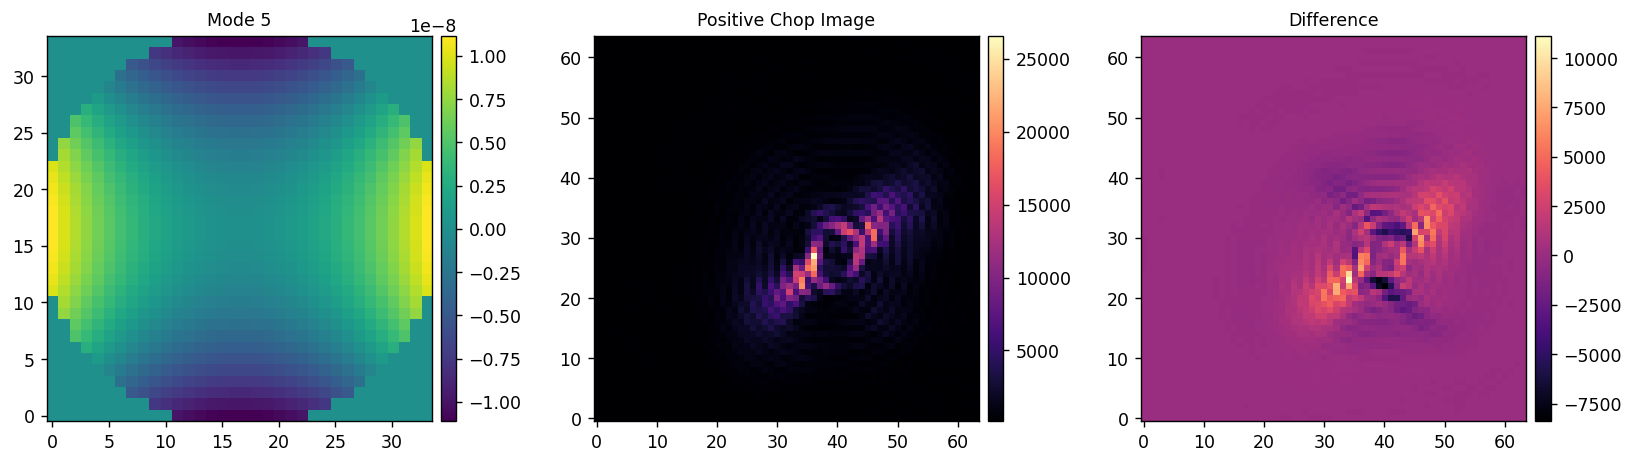

Calibrated mode 6/10 in 4.396s

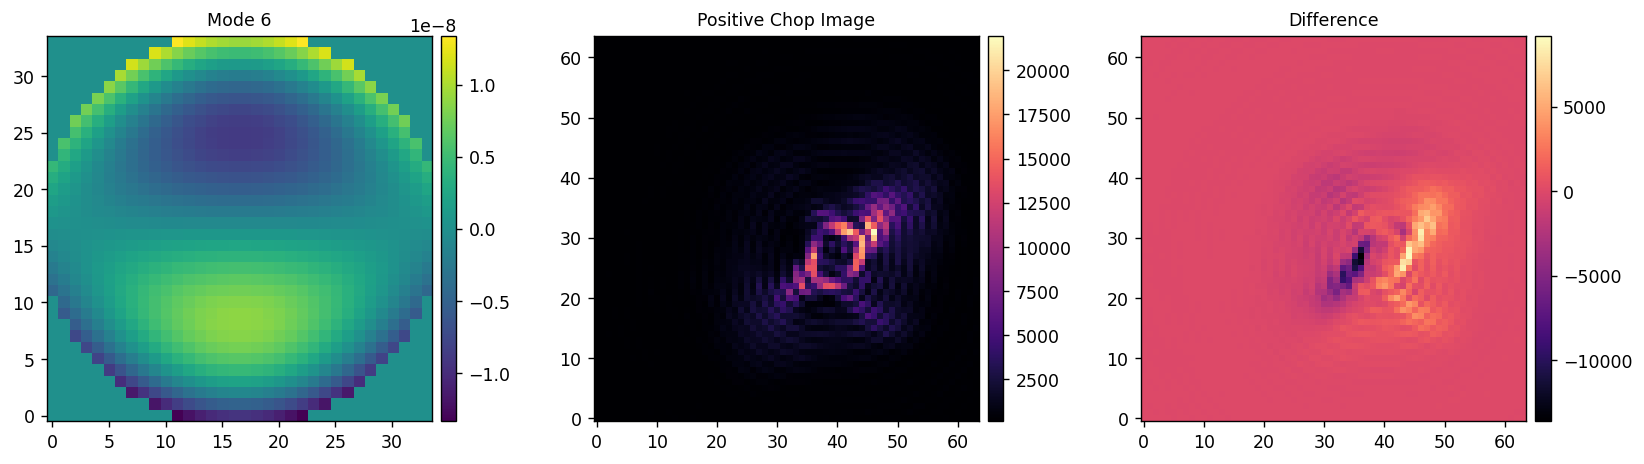

Calibrated mode 7/10 in 5.100s

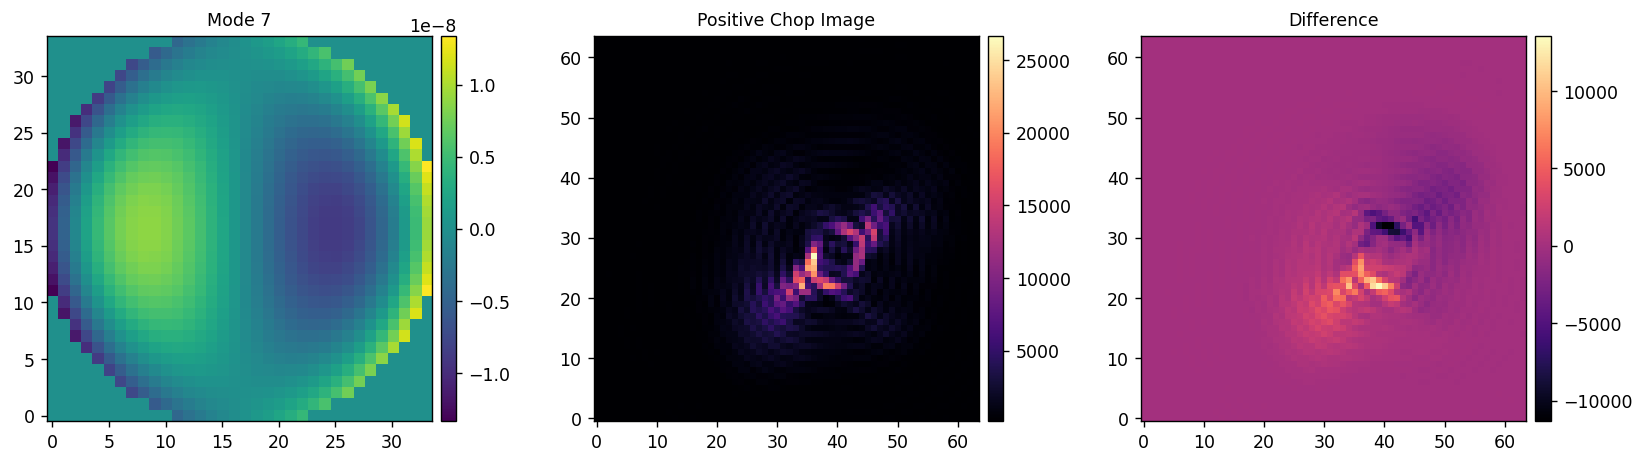

Calibrated mode 8/10 in 5.900s

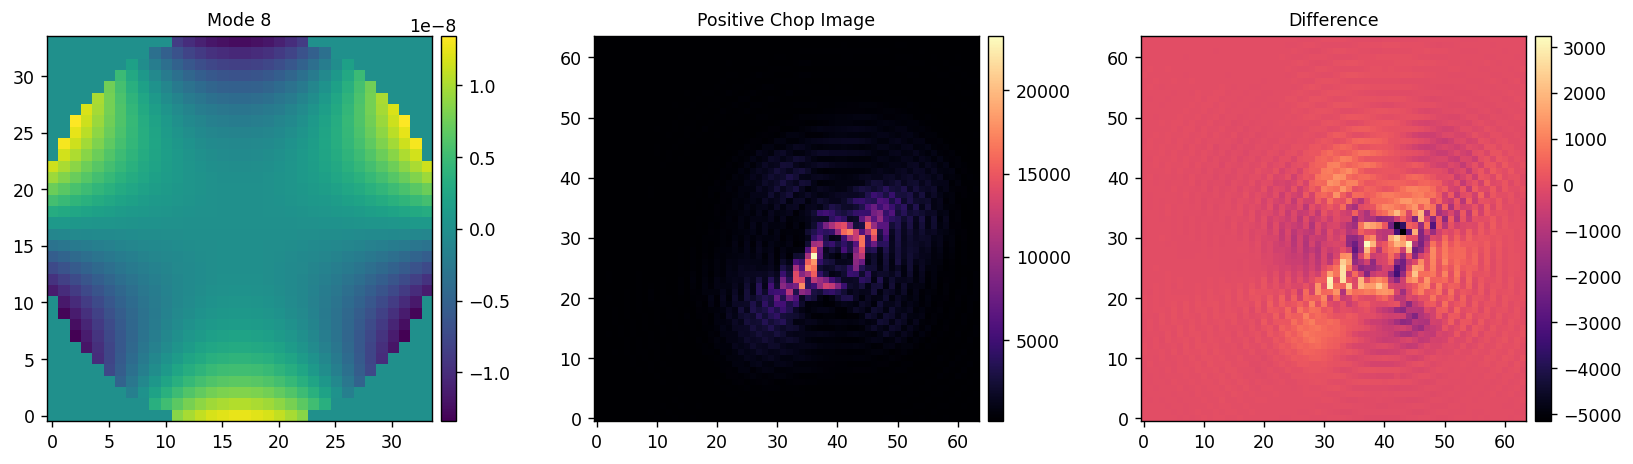

Calibrated mode 9/10 in 6.686s

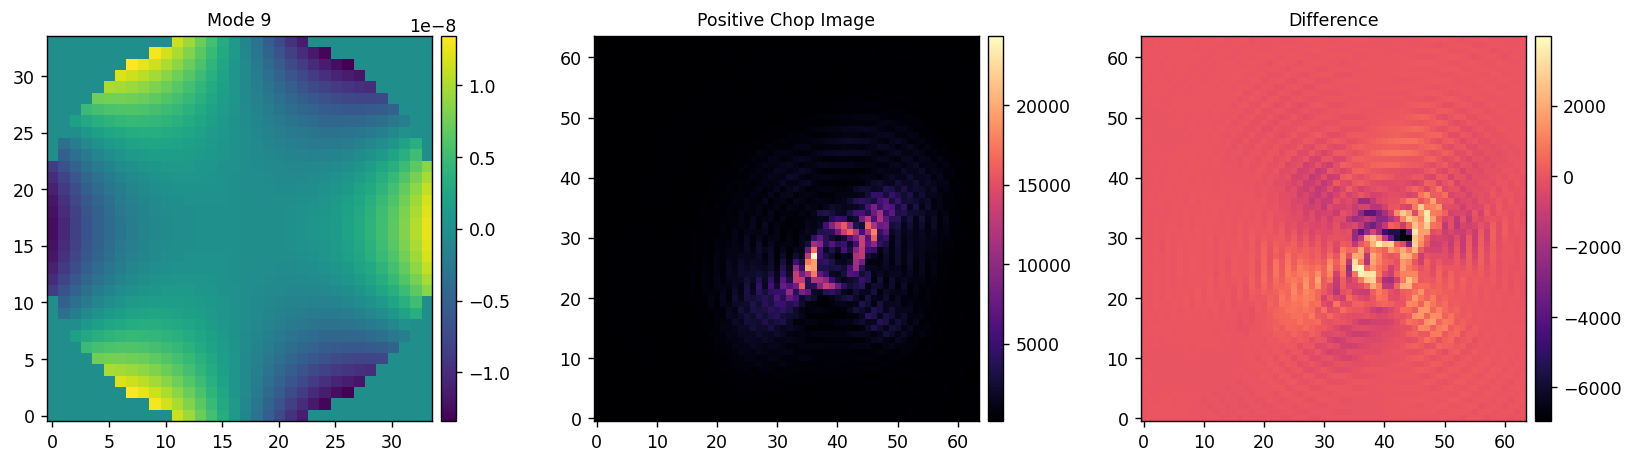

Calibrated mode 10/10 in 7.655s

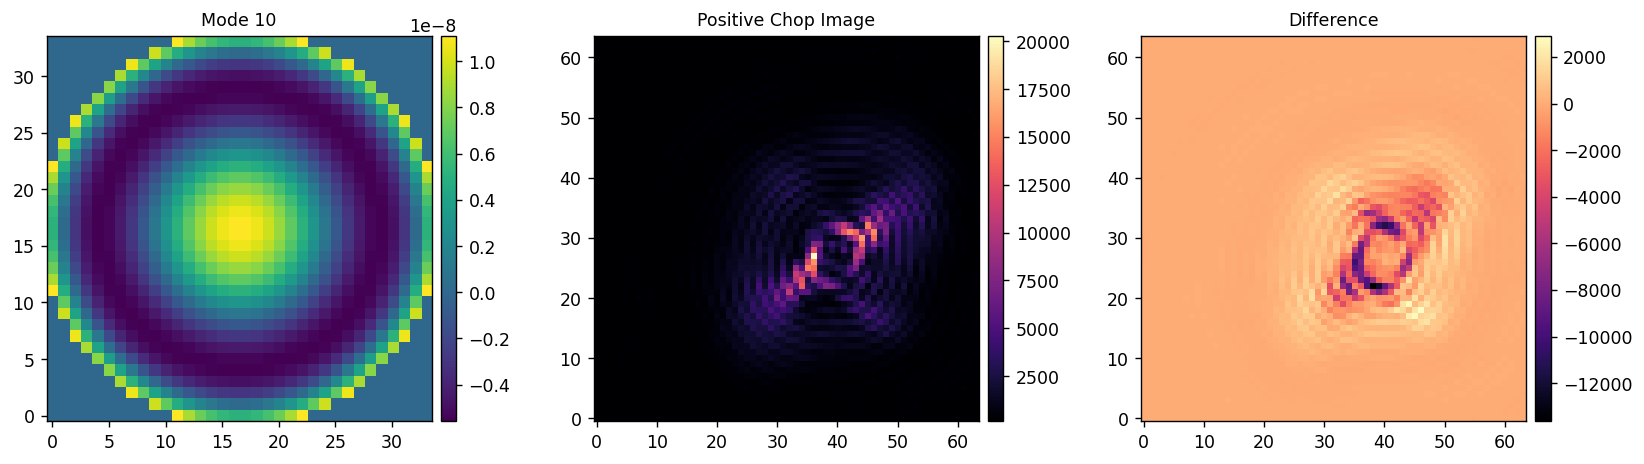

In [56]:
reload(llowfsc)
reload(dm)
reload(utils)

Nmodes = 10

dm_zer_mask = utils.pad_or_crop(dm.create_mask(Nact=Nact, return_np=1), DM_STREAMS[0].shape[0])
dm_zernike_modes = dm.create_zernike_modes(dm_zer_mask, nmodes=Nmodes, remove_modes=1, return_np=1)
# utils.imshow([dm_zernike_modes[0], dm_zernike_modes[3], dm_zernike_modes[-1]], cmaps=3*['viridis'])

take_im_params.update({
    'NFRAMES':50,
})

zer_rm, zer_response_cube = llowfsc.calibrate_dm_modes(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    dm_zernike_modes, 
    wfs_mask, 
    amp=5e-9, 
    flux_norm_coeff=flux_norm_coeff,
    # include_factor_2=True, 
    plot=True,
)


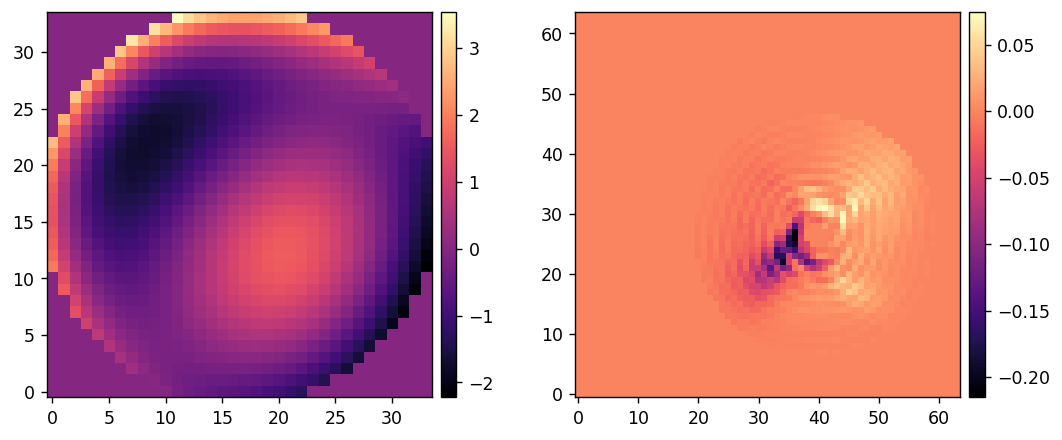

In [57]:
reload(utils)
P, U, s, Vt = utils.tikhonov_inverse(zer_rm, 0, return_all=1, return_np=1)

dm_modes = np.zeros((Nmodes, Nact, Nact))
wfs_modes = np.zeros((Nmodes, Ncamlo, Ncamlo))
for i in range(Nmodes):
    dm_modes[i, dm_mask] = Vt.dot(dm_zernike_modes[:, dm_mask])[i]
    # dm_modes[i, dm_mask] = Vt.T.dot(dm_zernike_modes[:, dm_mask])[i]
    wfs_modes[i, wfs_mask] = U.T[i] 

# dm_modes = Vt.dot(dm_zernike_modes[:, dm_mask])
# wfs_modes = U.T

# dm_modes.shape

i = 0
utils.imshow(
    [dm_modes[i], wfs_modes[i]]
)

# Start the LLOWFSC process

In [68]:
import multiprocessing

take_im_params.update({
    'NFRAMES':1,
})

def run_llowfsc():
    while True:
        llowfsc.run(
            take_im_fun,
            take_im_params,
            set_dm_fun,
            set_dm_params,
            get_dm_fun,
            get_dm_params,
            get_gains,
            ref_im,
            P,
            dm_zernike_modes,
            wfs_mask,
            dark_im=camlo_dark,
            get_zpo=get_zpo,
            get_zpo_params=get_zpo_params,
        )

llowfsc_proc = multiprocessing.Process(target=run_llowfsc)


In [69]:
llowfsc_proc.start()
print(f'LLOWFSC process ID: {llowfsc_proc.pid}',)

LLOWFSC process ID: 893324


In [70]:
llowfsc_proc.terminate()
set_dm_fun(np.zeros_like(dm_mask), **set_dm_params)

In [60]:
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.01]))

# Setup the ZPO process

In [61]:
def compute_zpo(
        DM_STREAMS,
        dm_mask,
        wfs_mask,
        response_matrix,
        dm_modal_matrix,
        ZPO_STREAM,
    ):
    zpo = np.zeros((wfs_mask.shape[0], wfs_mask.shape[1]))
    for i in range(len(DM_STREAMS)):
        zpo[wfs_mask] += response_matrix.dot( dm_modal_matrix.dot(1e-6*DM_STREAMS[i].grab_latest()[dm_mask]) )

    ZPO_STREAM.write(zpo)

zpo_params = {
    # 'DM_STREAMS':DM_STREAMS[1:],
    'DM_STREAMS':[DM_STREAMS[1]],
    'dm_mask':dm_mask,
    'wfs_mask':wfs_mask,
    'response_matrix':zer_rm, 'dm_modal_matrix':dm_zernike_modes[:, dm_mask]/952 ,
    # 'response_matrix':had_rm, 'dm_modal_matrix':dm_had_modes[:, dm_mask]/1024,
    'ZPO_STREAM':ZPO_STREAM,
}

In [31]:
set_dm_fun(3e-9 * dm_zernike_modes[2], DM_STREAMS[1])

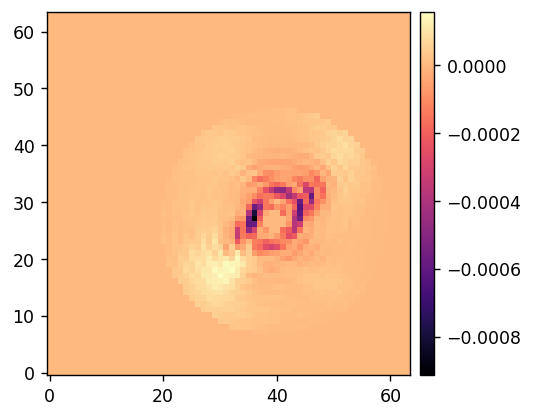

In [42]:
compute_zpo(**zpo_params)

zpo = ZPO_STREAM.grab_latest()

utils.imshow(
    [zpo]
)

In [93]:
%%timeit -n 1000
zpo = compute_zpo(**zpo_params)

42.3 μs ± 8.56 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [62]:
reload(llowfsc)
zpo_freq = 500

zpo_process = llowfsc.TimedThread(
    1/zpo_freq,
    compute_zpo,
    kwargs=zpo_params,
)

In [63]:
zpo_process.start()

In [51]:
zpo_process.cancel()

In [50]:
set_dm_fun(0e-9 * dm_zernike_modes[8], DM_STREAMS[1])

In [65]:
DM_STREAMS[0].name

'dm00disp01'